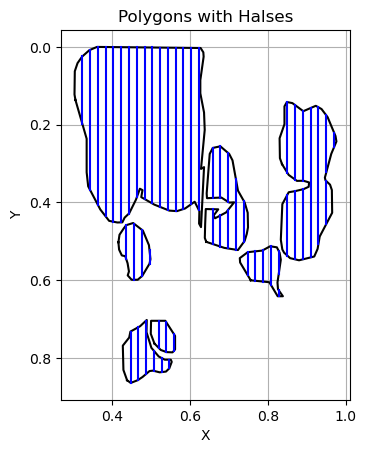

1 0.02,32(x: 0.32234375000000004, y: 0.024583333333333318)
1 0.02,32(x: 0.32234375000000004, y: 0.19719219219219228)
1 0.02,32(x: 0.34234375000000006, y: 0.00759999999999998)
1 0.02,32(x: 0.34234375000000006, y: 0.36759027777777786)
1 0.02,32(x: 0.3623437500000001, y: 2.280873248615249e-05)
1 0.02,32(x: 0.3623437500000001, y: 0.40581250000000013)
1 0.02,32(x: 0.3823437500000001, y: 0.00023134571521668383)
1 0.02,32(x: 0.3823437500000001, y: 0.4355555555555557)
1 0.02,32(x: 0.4023437500000001, y: 0.00043988269794721527)
1 0.02,32(x: 0.4023437500000001, y: 0.44938271604938274)
1 0.02,32(x: 0.42234375000000013, y: 0.0006484196806777465)
1 0.02,32(x: 0.42234375000000013, y: 0.4510930362982783)
1 0.02,32(x: 0.44234375000000015, y: 0.0008569566634082777)
1 0.02,32(x: 0.44234375000000015, y: 0.42837037037037023)
1 0.02,32(x: 0.46234375000000016, y: 0.0010654936461388092)
1 0.02,32(x: 0.46234375000000016, y: 0.38702604245449457)
1 0.02,32(x: 0.4823437500000002, y: 0.0012740306288693403)
1 0.02

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, LineString
xy=""
def parse_data(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()

    polygons = []
    current_polygon = []

    for line in lines:
        data = line.strip().split(" ")[1:]  # Удаляем первый элемент
        if not data:  # Если строка пустая, пропускаем
            continue
        
        coords = list(map(float, data))
        current_polygon.extend(zip(coords[::2], coords[1::2]))  # Пара (x, y)

        if line.startswith('0'):
            if current_polygon:
                polygons.append(Polygon(current_polygon))
                current_polygon = []

    if current_polygon:
        polygons.append(Polygon(current_polygon))

    return polygons

def create_halses(polygon, spacing):
    minx, miny, maxx, maxy = polygon.bounds
    halses = []
    x = minx
    while x <= maxx:  # Изменено на <= для включения maxx
        line = LineString([(x, miny), (x, maxy)])
        intersection = polygon.intersection(line)
        if intersection.is_empty:
            x += spacing
            continue
        if intersection.geom_type == 'MultiLineString':
            for geom in intersection.geoms:  # Исправлено на .geoms
                halses.append(geom)
        elif intersection.geom_type == 'LineString':
            halses.append(intersection)
        x += spacing
    return halses

def plot_polygons_with_halses(polygons, spacing):
    fig, ax = plt.subplots()
    
    for polygon in polygons:
        x, y = polygon.exterior.xy
        ax.plot(x, y, color='black')

        # Генерация галсов для текущего полигона
        halses = create_halses(polygon, spacing)
        for line in halses:
            x, y = line.xy
            ax.plot(x, y, color='blue')

    ax.set_aspect('equal')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title('Polygons with Halses')
    plt.grid(True)  # Добавляем сетку для удобства
    plt.gca().invert_yaxis()  # Инвертируем ось Y
    plt.show()

def print_polygon_info(polygons, spacing):
    for i, polygon in enumerate(polygons):
        halses = create_halses(polygon, spacing)
        num_points = 0
        coordinates = []  # Список для хранения координат

        for line in halses:
            x_coords = line.xy[0]
            y_coords = line.xy[1]
            num_points += len(x_coords)
            coordinates.extend(zip(x_coords, y_coords))  # Добавляем пары (x, y)

        for x, y in coordinates:
            print(f"{i + 1} {spacing},{num_points}(x: {x}, y: {y})")
            

# Укажите путь к вашему файлу
file_path = '.ipynb_checkpoints/PrujectNN/example_lables/f2_148_jpg.rf.632581c23f4b95332891e17427fda50b.txt'
polygons = parse_data(file_path)

# Визуализация с галсами
spacing = 0.02  # Расстояние между галсами
plot_polygons_with_halses(polygons, spacing)

# Вывод информации о полигонах
print_polygon_info(polygons, spacing)